# Data Wrangling

In [163]:
import os
import pandas as pd
import numpy as np

from scipy.stats import uniform, uniform, loguniform, randint
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.inspection import permutation_importance
from sklearn.metrics import average_precision_score, brier_score_loss, log_loss, make_scorer, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification

import xgboost as xgb


In [164]:
# Assume root directory is './TrainingData'
root_dir = './TrainingData'

TRAIN_list = []
LABELS_list = []
fold_indices = []

SALE_COLUMNS = ["Actual Loss Calculation", "Zero Balance Removal UPB", "Net Sales Proceeds", 
                "Delinquent Accrued Interest", "Expenses", "MI Recoveries", "Non MI Recoveries"]

MISC_COLUMNS_TO_DROP = ["MSA", 'Postal Code', 'Major Stress', "Monthly Reporting Period",
                        'Distress Date', 'Zero Balance Code', 'Unresolved', 'Last Time Current',
                         'Property State', 'Current Loan Delinquency Status', 'Loan Sequence Number',
                         'Estimated Loan-to-Value (ELTV)']

fold = 0 

# Load in all files from TrainingData Folder
for year in range(2000, 2018+1):
    year_path = os.path.join(root_dir, f"Year{year}")
    if os.path.isdir(year_path):
        for file in os.listdir(year_path):
            if file.endswith('.parquet'):
                file_path = os.path.join(year_path, file)
                df = pd.read_parquet(file_path)
                df = df[(df["Major Stress"] == 1) & ~(df["Unresolved"] == 1)]
                TRAIN_list.append(df.drop(columns=['Default Flag'])) 
                LABELS_list.append(df['Default Flag'])               
                fold_indices.extend([fold] * len(df))
        fold += 1

TRAIN = pd.concat(TRAIN_list).reset_index(drop=True)
TRAIN = TRAIN.drop(columns=SALE_COLUMNS)


In [165]:
TRAIN = TRAIN.drop(columns=MISC_COLUMNS_TO_DROP)
categorical_cols = TRAIN.select_dtypes(include=['object', 'category']).columns.tolist()

TRAIN = pd.get_dummies(TRAIN, columns=categorical_cols, drop_first=True)
LABELS = pd.concat(LABELS_list).reset_index(drop=True)
LABELS.fillna(0, inplace=True)

In [166]:
TRAIN["Est. Home Val at Origination"] = TRAIN["Original UPB"] / TRAIN["Original Combined Loan-to-Value (CLTV)"] * 100
TRAIN["Est. Current Home Val"] = TRAIN["Est. Home Val at Origination"] * (TRAIN["HPI Change %"] + 1)

TRAIN["Geographic Est. ELTV"] = TRAIN["Current Actual UPB"] / TRAIN["Est. Current Home Val"]

def estimate_months_remaining(row):
    L = row['Original UPB']
    B = row['Current Actual UPB']
    annual_rate = row["Original Interest Rate"]
    N_orig = row['Original Loan Term']
    
    r = annual_rate / 100 / 12

    if r == 0:
        P = L / N_orig
    else:
        P = (L * r) / (1 - (1 + r) ** -N_orig)

    if P <= r * B:
        return np.nan  # Loan isn't amortizing

    N_remaining = (np.log(P) - np.log(P - r * B)) / np.log(1 + r)
    return round(N_remaining)

TRAIN.loc[TRAIN["Remaining Months to Legal Maturity"].isna(), "Remaining Months to Legal Maturity"] = TRAIN[TRAIN["Remaining Months to Legal Maturity"].isna()].apply(lambda row : estimate_months_remaining(row), axis=1)

In [167]:
TRAIN = TRAIN[['Credit Score', 'Mortgage Insurance Percentage (MI %)',
       'Number of Units', 'Original Combined Loan-to-Value (CLTV)',
       'Original Debt-to-Income (DTI) Ratio', 'Original UPB',
       'Original Loan-to-Value (LTV)', 'Original Interest Rate',
       'Original Loan Term', 'Number of Borrowers',
       'Property Valuation Method', 'Current Actual UPB', 'Loan Age',
       'Remaining Months to Legal Maturity', 'Modification Flag',
       'Current Interest Rate', 'Current Deferred UPB',
       'Deferred Payment Plan', 'Delinquency Due to Disaster',
       'Interest Bearing UPB', 'Numeric Delinquency', 'MaxPriorDelinquency',
       'Current Unemployment Rate',
       'HPI Change %', 'Unemployment Rate Change 1Y',
       'First Time Homebuyer Flag_N', 'First Time Homebuyer Flag_Y',
       'Occupancy Status_P', 'Occupancy Status_S', 'Property Type_CP',
       'Property Type_MH', 'Property Type_PU', 'Property Type_SF',
       'Loan Purpose_N', 'Loan Purpose_P', 'Program Indicator_F',
       'Program Indicator_H', 'Mortgage Insurance Cancellation Indicator_7',
       'Mortgage Insurance Cancellation Indicator_N',
       'Mortgage Insurance Cancellation Indicator_Y',
       'Borrower Assistance Status Code_R',
       'Borrower Assistance Status Code_T',
       'Geographic Est. ELTV']]

# Mutual Information

In [120]:
from sklearn.feature_selection import mutual_info_classif

# X: your feature matrix
# y: your binary target

mi_scores = []
for i in range(TRAIN.shape[1]):  # loop over features
    Xi = TRAIN.iloc[:, i]        # <-- FIX here
    mask = ~Xi.isna()            # better Pandas NaN mask
    mi = mutual_info_classif(Xi[mask].values.reshape(-1, 1), LABELS[mask])
    mi_scores.append(mi[0])

In [ ]:
mi_series = pd.Series(mi_scores, index=TRAIN.columns)

# Sort from most informative to least
mi_series = mi_series.sort_values(ascending=False)

print(mi_series)


# Data Splitting

In [168]:
state = 40

X_train, X_val, y_train, y_val = train_test_split(
    TRAIN, LABELS, test_size=0.2, random_state=state, stratify=LABELS
)

print(f"Train shape: {X_train.shape}, Validation shape: {X_val.shape}")

Train shape: (27696, 43), Validation shape: (6924, 43)


# Logistic Regression

In [142]:
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
model.fit(X_train, y_train)

model.fit(X_train, y_train)

predictions = model.predict(X_val)

accuracy = model.score(X_val, y_val)
print(accuracy)

0.6627671865973426


# XGBoost

In [210]:
NumParamSearchIterations = 100

param_distributions = {
    'n_estimators': range(15, 30),
    'learning_rate': uniform(0.01, 0.08),  # Slower learning
    'max_depth': range(4, 10),
    'subsample': uniform(0.7, 0.3),
    'colsample_bytree': uniform(0.7, 0.3),
}

# Setup RandomizedSearchCV
hyperparameter_tuning = RandomizedSearchCV(
    xgb.XGBClassifier(
        random_state=state,
        objective='binary:logistic',
    ),
    scoring='neg_brier_score',  # Focus on probability calibration
    param_distributions=param_distributions,
    n_iter=NumParamSearchIterations,
    cv=3,
    random_state=state,
    verbose=2,
    n_jobs=6
)

search = hyperparameter_tuning.fit(X_train, y_train,verbose=True)

# Output best results
print("\nBest Hyperparameters:", search.best_params_)
print("Best CV Brier Score (negated):", search.best_score_)

# Extract best model
best_model = search.best_estimator_

# Final validation predictions on untouched validation set
y_val_pred_probs = best_model.predict_proba(X_val)[:, 1]
y_val_preds = best_model.predict(X_val)

# Final validation metrics
ap_score = average_precision_score(y_val, y_val_pred_probs)
brier = brier_score_loss(y_val, y_val_pred_probs)
logloss = log_loss(y_val, y_val_pred_probs)
accuracy = accuracy_score(y_val, y_val_preds)

print("\nValidation Metrics:")
print(f"Average Precision Score: {ap_score:.4f}")
print(f"Brier Score: {brier:.6f}")
print(f"Log Loss: {logloss:.6f}")
print(f"Accuracy: {accuracy}")


Fitting 3 folds for each of 100 candidates, totalling 300 fits

Best Hyperparameters: {'colsample_bytree': 0.9697682653943345, 'learning_rate': 0.07728215383431018, 'max_depth': 8, 'n_estimators': 28, 'subsample': 0.8303777091753339}
Best CV Brier Score (negated): -0.20510587631929356

Validation Metrics:
Average Precision Score: 0.7749
Brier Score: 0.207046
Log Loss: 0.600735
Accuracy: 0.6691218948584633


In [190]:
result = permutation_importance(
    best_model,              # Your trained model
    X_val,                   # Validation features
    y_val,                   # Validation targets
    scoring='neg_brier_score',  # Keep the same scoring as your CV
    n_repeats=10,             # How many times to shuffle each feature
    random_state=state,
    n_jobs=-1                 # Use all CPUs
)

sorted_idx = np.argsort(result.importances_mean)[::-1]

for idx in sorted_idx:
    print(f"{X_val.columns[idx]}: {result.importances_mean[idx]:.6f} ± {result.importances_std[idx]:.6f}")

Geographic Est. ELTV: 0.016640 ± 0.000612
MaxPriorDelinquency: 0.005754 ± 0.000426
Original UPB: 0.002826 ± 0.000307
Credit Score: 0.001938 ± 0.000169
Occupancy Status_P: 0.000804 ± 0.000091
HPI Change %: 0.000550 ± 0.000059
Current Interest Rate: 0.000469 ± 0.000065
Original Loan-to-Value (LTV): 0.000378 ± 0.000069
Original Combined Loan-to-Value (CLTV): 0.000274 ± 0.000064
Original Interest Rate: 0.000273 ± 0.000062
Interest Bearing UPB: 0.000260 ± 0.000046
Current Actual UPB: 0.000208 ± 0.000066
Numeric Delinquency: 0.000126 ± 0.000047
Loan Age: 0.000073 ± 0.000037
Property Type_SF: 0.000069 ± 0.000010
Unemployment Rate Change 1Y: 0.000064 ± 0.000028
Current Unemployment Rate: 0.000057 ± 0.000014
Original Debt-to-Income (DTI) Ratio: 0.000055 ± 0.000028
Loan Purpose_P: 0.000033 ± 0.000026
Property Type_PU: 0.000015 ± 0.000008
Remaining Months to Legal Maturity: 0.000014 ± 0.000013
Modification Flag: 0.000007 ± 0.000007
Mortgage Insurance Cancellation Indicator_N: 0.000004 ± 0.000011


# Calibration

In [211]:
df = pd.DataFrame({
    'y_true': y_val,
    'y_prob': y_val_pred_probs
})
df['prob_bin'] = pd.qcut(df['y_prob'], q=20, labels=False)

# Group by bin and calculate average predicted probability and actual event rate
calibration_df = df.groupby('prob_bin').agg(
    avg_predicted_prob=('y_prob', 'mean'),
    actual_rate=('y_true', 'mean'),
    count=('y_true', 'count')
).reset_index()

# Optional: round values for cleaner display
calibration_df = calibration_df.round(4)

In [171]:
calibration_df

,prob_bin,avg_predicted_prob,actual_rate,count
0,0,0.1833,0.1700,347
1,1,0.2804,0.2601,346
2,2,0.3430,0.3815,346
3,3,0.3878,0.3815,346
4,4,0.4303,0.4509,346
5,5,0.4662,0.4422,346
6,6,0.5013,0.4928,347
7,7,0.5325,0.5347,346
8,8,0.5641,0.5289,346
9,9,0.5930,0.5665,346


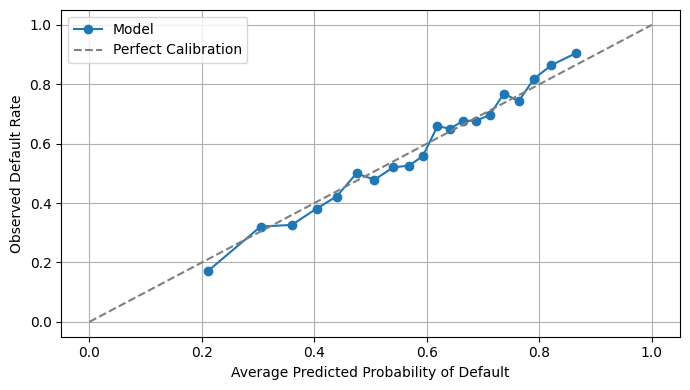

In [212]:
import matplotlib.pyplot as plt

# Assuming your DataFrame is called `calibration_df`
x = calibration_df['avg_predicted_prob']
y = calibration_df['actual_rate']

plt.figure(figsize=(7, 4))
plt.plot(x, y, marker='o', label='Model')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')

plt.xlabel('Average Predicted Probability of Default')
plt.ylabel('Observed Default Rate')
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("Charts/Model2Calibration.png")

plt.show()


# Refit and Save

In [213]:
import pickle

best_model_full = xgb.XGBClassifier(
    **search.best_params_,
    random_state=state,
    objective='binary:logistic'
)
best_model_full.fit(TRAIN, LABELS)

with open("Models/DefaultGivenDistress.pkl", "wb") as f:
    pickle.dump(best_model_full, f)